In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("vendas_sorvete_final.csv", sep=';', decimal='.')

In [43]:
# selecao de colunas
X = df[
    [
        "Temp. [Hora] (C)",
        "Umi. (%)",
        "Nebulosidade (Decimos)",
        "Chuva [Diaria] (mm)",
        "fim_de_semana",
        "feriado",
        "promocao"
    ]
]

y = df["vendas_sorvete"]

In [44]:
# separacao treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [45]:
# modelo
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
# previsao
y_pred = model.predict(X_test)

In [47]:
# metricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [48]:
print("MAE:", mae)
print("R2:", r2)

MAE: 6.293881079162032
R2: 0.9564602641498332


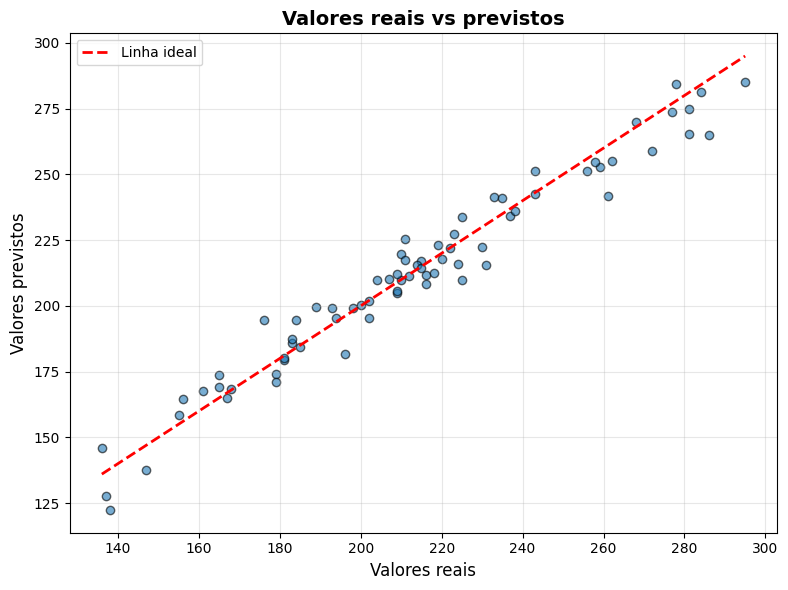

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Linha ideal')
plt.xlabel("Valores reais", fontsize=12)
plt.ylabel("Valores previstos", fontsize=12)
plt.title("Valores reais vs previstos", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_real_vs_previsto.png', dpi=300, bbox_inches='tight')
plt.show()

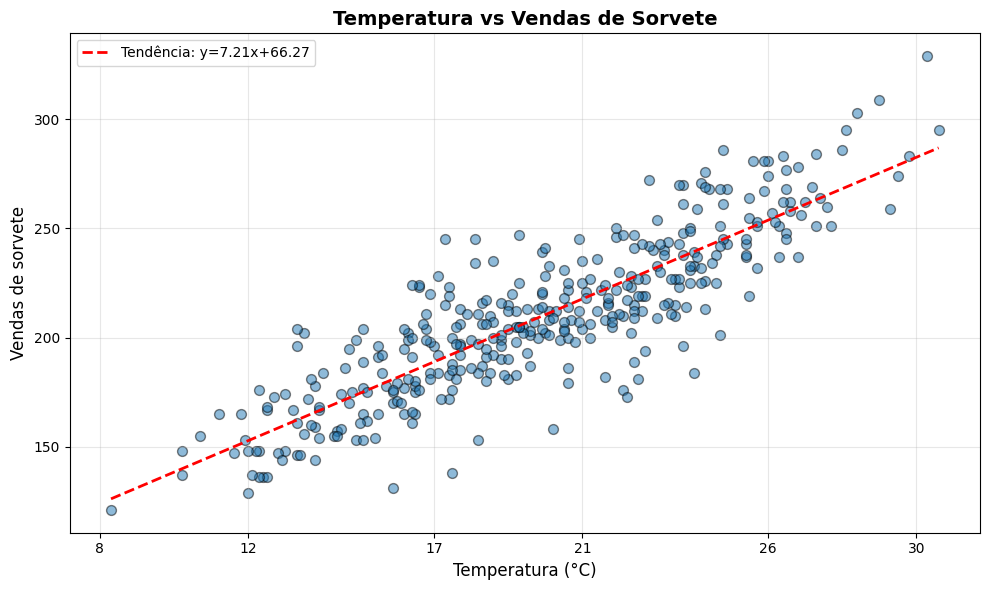

In [50]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(df["Temp. [Hora] (C)"], df["vendas_sorvete"], alpha=0.5, edgecolors='k', s=50)

# Adiciona linha de tendência
z = np.polyfit(df["Temp. [Hora] (C)"], df["vendas_sorvete"], 1)
p = np.poly1d(z)
temp_sorted = sorted(df["Temp. [Hora] (C)"])
plt.plot(temp_sorted, p(temp_sorted), "r--", linewidth=2, label=f'Tendência: y={float(z[0]):.2f}x+{float(z[1]):.2f}')

plt.xlabel("Temperatura (°C)", fontsize=12)
plt.ylabel("Vendas de sorvete", fontsize=12)
plt.title("Temperatura vs Vendas de Sorvete", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Simplifica o eixo X - apenas 5-6 valores
temp_min = df["Temp. [Hora] (C)"].min()
temp_max = df["Temp. [Hora] (C)"].max()
plt.xticks(np.linspace(temp_min, temp_max, 6).astype(int))

plt.tight_layout()
plt.savefig('grafico_temperatura_vs_vendas.png', dpi=300, bbox_inches='tight')
plt.show()